In [1]:
import os
import random
import math
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

In [2]:
import jupyter_black

jupyter_black.load()

In [3]:
plt.style.use("../src/mpl_style.txt")

In [4]:
random.seed(0)
rng = np.random.default_rng(seed=0)

### Excess word simulation
to investigate the behavior of the LLM usage lower bound estimate
diff / (1-proj) when true LLM usage is known.

Procedure:
- create 2 word occurrence matrices (100000 texts x 1000 words), one 
before and one after LLM introduction
- create probability distribution for the mean frequencies of words
(this can be guided by the observed frequencies).
- draw from this dist to get the pre-LLM mean frequencies for any word, 
then use this mean as the binomal mean to draw samples
- create prob. dist of differences (increase in usage after LLM introduction), 
which will be added to the mean frequencies of a given percentage of texts,
representing the fraction of texts using LLMs 
The differences somehow need to depend on the frequency, such that a word with
freqeuncy 0.001 increases to 0.002 and not to 0.2, and a word with frequency 
0.1 to 0.2 and not 0.101
- determine excess words (are all words we used excess words by definition?)
- sort excess words by pre-LLM frequency and make lists with different cutoffs
- for each cutoff, compute word list frequency, difference and lower bound 
estimate
- repeat for different LLM usage likelihoods

comments
- binomial uncertainty for stimulation
- increase number of cutoffs (should do the same as binomial uncertainty)
- for real data, propagate uncertainty of linear regression
- check how linear regression for whole year is done (averages)

In [5]:
n_words = 100
n_texts = 100000

In [6]:
def delta_f(x: float) -> float:
    # should d also depend on x, but inversely? more variation for smaller freqs
    d = random.uniform(0.5, 5)
    d = x * d
    if d + x <= 1:
        return d
    else:
        return delta_f(x)

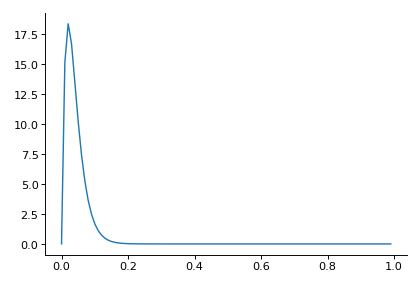

In [7]:
fig = plt.figure(figsize=(3, 2), layout="constrained")
x = np.arange(0, 1, 0.01)
gamma_shape = 2
gamma_scale = 0.02
y = sp.stats.gamma.pdf(x, a=gamma_shape, scale=gamma_scale)
plt.plot(x, y)

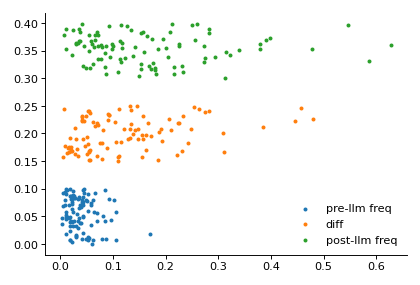

In [8]:
# should p be more skewed towards 0?
# p = np.random.uniform(low=0.0001, high=0.5, size=n_words)
p = rng.gamma(shape=gamma_shape, scale=gamma_scale, size=n_words)
delta = list(map(delta_f, p))
q = p + delta

fig = plt.figure(figsize=(3, 2), layout="constrained")

plt.scatter(p, rng.uniform(low=0, high=0.1, size=n_words), label="pre-llm freq", s=5)
plt.scatter(delta, rng.uniform(low=0.15, high=0.25, size=n_words), label="diff", s=5)
plt.scatter(q, rng.uniform(low=0.3, high=0.4, size=n_words), label="post-llm freq", s=5)
plt.legend()
plt.show()

In [9]:
llm_use = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
X_before = {}
X_after = {}
counts_before = {}
counts_after = {}
freqs_before = {}
freqs_after = {}

for l in llm_use:
    X_b = np.zeros((n_words, n_texts))
    X_a = np.zeros((n_words, n_texts))
    k = int(l * n_texts)
    for i in range(n_words):
        X_b[i, :] = rng.binomial(1, p[i], n_texts)
        X_a[i, k:] = rng.binomial(1, p[i], n_texts - k)
        X_a[i, :k] = rng.binomial(1, q[i], k)
    X_before[l] = X_b
    X_after[l] = X_a

    counts_before[l] = np.sum(X_b, axis=1)
    counts_after[l] = np.sum(X_a, axis=1)

    freqs_before[l] = (counts_before[l] + 1) / (n_texts + 1)
    freqs_after[l] = (counts_after[l] + 1) / (n_texts + 1)

In [10]:
def se(p: float, q: float, n: int):
    if q == 1.0:
        q = 0.9999999999999999
    var = (p * (1 - p) * (q - 1) ** 2) / ((1 - p) ** 4 * n) + (q * (1 - q)) / (
        (1 - p) ** 2 * n
    )
    return math.sqrt(var)

In [11]:
se(0.9999, 1, n_texts)

3.332000937314744e-07

In [12]:
cutoffs = [0.0002, 0.0005, 0.001, 0.002, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1.0]

group_freqs_before = {}
group_freqs_after = {}
diff = {}
low_bound = {}
ses = {}

for l in llm_use:

    group_freqs_b = np.zeros(len(cutoffs))
    group_freqs_a = np.zeros(len(cutoffs))

    for i, cutoff in enumerate(cutoffs):

        ind = freqs_before[l] < cutoff
        group_counts_b = np.sum(np.sum(X_before[l][ind, :], axis=0) > 0)
        group_counts_a = np.sum(np.sum(X_after[l][ind, :], axis=0) > 0)
        group_freqs_b[i] = (group_counts_b + 1) / (n_texts + 1)
        group_freqs_a[i] = (group_counts_a + 1) / (n_texts + 1)

    group_freqs_before[l] = group_freqs_b
    group_freqs_after[l] = group_freqs_a
    diff[l] = group_freqs_a - group_freqs_b
    low = diff[l] / (1 - group_freqs_b)
    low_bound[l] = np.nan_to_num(low)
    ses[l] = list(map(se, group_freqs_b, group_freqs_a, [n_texts] * len(group_freqs_a)))

In [13]:
for l in llm_use:
    print(group_freqs_before[l])

[9.99990000e-06 9.99990000e-06 9.99990000e-06 9.99990000e-06
 1.28498715e-02 6.57693423e-02 2.72757272e-01 8.48071519e-01
 9.69640304e-01 9.81860181e-01 9.81860181e-01 9.81860181e-01]
[9.99990000e-06 9.99990000e-06 9.99990000e-06 9.99990000e-06
 1.32498675e-02 4.78595214e-02 2.87867121e-01 8.56901431e-01
 9.70310297e-01 9.82940171e-01 9.82940171e-01 9.82940171e-01]
[9.99990000e-06 9.99990000e-06 9.99990000e-06 1.87998120e-03
 1.27398726e-02 4.82595174e-02 2.86667133e-01 8.49901501e-01
 9.69200308e-01 9.81610184e-01 9.81610184e-01 9.81610184e-01]
[9.99990000e-06 9.99990000e-06 9.99990000e-06 1.83998160e-03
 1.33498665e-02 5.74994250e-02 2.90557094e-01 8.51081489e-01
 9.70020300e-01 9.81920181e-01 9.81920181e-01 9.81920181e-01]
[9.99990000e-06 9.99990000e-06 9.99990000e-06 9.99990000e-06
 1.33998660e-02 4.80095199e-02 2.88287117e-01 8.49831502e-01
 9.69310307e-01 9.81780182e-01 9.81780182e-01 9.81780182e-01]
[9.99990000e-06 9.99990000e-06 9.99990000e-06 9.99990000e-06
 1.36598634e-02 6.6

In [14]:
diff[0.5]

array([0.        , 0.        , 0.        , 0.        , 0.01731983,
       0.06663933, 0.2198678 , 0.07543925, 0.01506985, 0.00925991,
       0.00925991, 0.00925991])

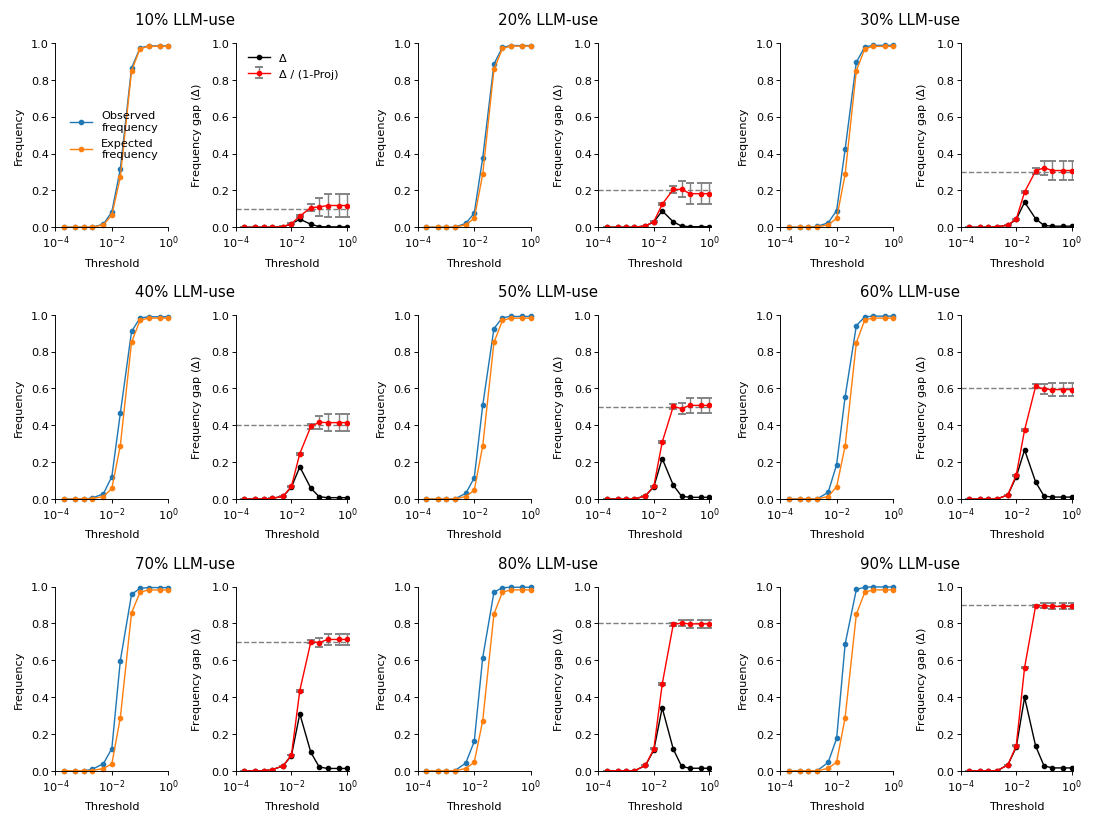

In [15]:
fig = plt.figure(figsize=(8, 6), layout="constrained")
subfigs = fig.subfigures(3, 3)

for subfig, l in zip(subfigs.flat, llm_use):
    axs = subfig.subplots(1, 2)
    subfig.suptitle(f"{int(l*100)}% LLM-use")

    axs[0].plot(
        cutoffs, group_freqs_after[l], ".-", clip_on=False, label="Observed\nfrequency"
    )
    axs[0].plot(
        cutoffs, group_freqs_before[l], ".-", clip_on=False, label="Expected\nfrequency"
    )

    axs[0].set_xscale("log")
    axs[0].set_xlim([1e-4, 1])
    axs[0].set_ylim([0, 1])
    axs[0].set_ylabel("Frequency")
    axs[0].set_xlabel("Threshold")
    if l == 0.1:
        axs[0].legend()

    axs[1].plot(cutoffs, diff[l], "k.-", label="Δ")
    # axs[1].plot(cutoffs, low_bound[l], "r.-", label="Δ / (1-Proj)")
    axs[1].errorbar(
        cutoffs,
        low_bound[l],
        yerr=list(map(lambda x: x * 2, ses[l])),  # ±2 standard errors
        fmt="r.-",
        ecolor="grey",
        capsize=2,
        label="Δ / (1-Proj)",
    )
    axs[1].axhline(l, color="grey", linestyle="--")

    """
    i = int(np.argmax(low_bound[l]))
    axs[1].text(
        cutoffs[i] + 0.01,
        low_bound[l][i] + 0.04,
        f"{low_bound[l][i]:.2f}",
        va="center",
        bbox=dict(
            edgecolor="none", facecolor="#666666", alpha=0.5, boxstyle="round,pad=.2"
        ),
    )
    i = int(np.argmax(diff[l]))
    axs[1].text(
        cutoffs[i] + 0.01,
        diff[l][i] + 0.04,
        f"{diff[l][i]:.2f}",
        va="center",
        bbox=dict(
            edgecolor="none", facecolor="#666666", alpha=0.5, boxstyle="round,pad=.2"
        ),
    )"""
    axs[1].set_xscale("log")
    axs[1].set_xlim([1e-4, 1.15])
    axs[1].set_ylim([0, 1])
    axs[1].set_ylabel(r"Frequency gap ($\Delta$)")
    axs[1].set_xlabel("Threshold")
    if l == 0.1:
        axs[1].legend()

plt.savefig(
    os.path.join("../results/plots/ground_truth_simulation", f"{n_words}_words.png"),
    dpi=300,
)